In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import MinMaxScaler

In [116]:
X_train_processed = pd.read_csv(
    "../data/processed/X_train_processed.csv"
)

X_test_processed = pd.read_csv(
    "../data/processed/X_test_processed.csv"
)

print("Training/reference data:", X_train_processed.shape)
print("Test/holdout data:", X_test_processed.shape)

Training/reference data: (4090, 6)
Test/holdout data: (1023, 6)


In [117]:
df = pd.read_csv("../data/raw/PMAY-U_2025_dataset.csv")

df = df.rename(columns={
    df.columns[0]: "Country",
    df.columns[1]: "State",
    df.columns[2]: "Year",
    df.columns[3]: "City",
    df.columns[4]: "Investment",
    df.columns[5]: "Central_assistance_sanctioned",
    df.columns[6]: "Central_assistance_released",
    df.columns[7]: "Houses_sanctioned",
    df.columns[8]: "Houses_grounded",
    df.columns[9]: "Houses_completed"
})

df.head()

,Country,State,Year,City,Investment,Central_assistance_sanctioned,Central_assistance_released,Houses_sanctioned,Houses_grounded,Houses_completed
0,India,Andaman And Nicobar Islands,"Calendar Year (Jan - Dec), 2025","Port Blair, Municipality",95.83,5.84,2.93,376.0,376.0,151.0
1,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025","Addanki, Municipality",194.41,66.53,34.02,4388.0,3228.0,2173.0
2,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025","Adoni, Municipality",701.24,220.56,129.20,14605.0,11305.0,9405.0
3,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025","Akiveedu, Town Panchayat",42.86,17.22,9.77,1136.0,963.0,579.0
4,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025","Allagadda, Municipality",202.95,53.74,45.32,3537.0,3454.0,3266.0


Isolation Forest


In [118]:
model_iso = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

model_iso.fit(X_train_processed)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [119]:
iso_pred = model_iso.score_samples(X_test_processed)

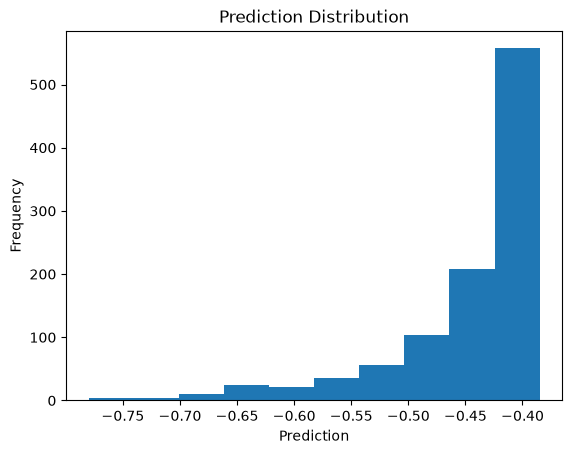

In [120]:
plt.hist(iso_pred)
plt.xlabel("Prediction")
plt.ylabel("Frequency")
plt.title("Prediction Distribution")
plt.show()

Local Outlier Factor


In [121]:
model_lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination="auto",
    novelty=True
)

model_lof.fit(X_train_processed)

,"novelty novelty: bool, default=FalseBy default, LocalOutlierFactor is only meant to be used for outlierdetection (novelty=False). Set novelty to True if you want to useLocalOutlierFactor for novelty detection. In this case be aware thatyou should only use predict, decision_function and score_sampleson new unseen data and not on the training set; and note that theresults obtained this way may differ from the standard LOF results... versionadded:: 0.20",True
,"n_neighbors n_neighbors: int, default=20Number of neighbors to use by default for :meth:`kneighbors` queries.If n_neighbors is larger than the number of samples provided,all samples will be used.",20
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf is size passed to :class:`BallTree` or :class:`KDTree`. This canaffect the speed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float, default=2Parameter for the Minkowski metric from:func:`sklearn.metrics.pairwise_distances`. When p = 1, thisis equivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. When fitting this is used to define thethreshold on the scores of the samples.- if 'auto', the threshold is determined as in the original paper,- if a float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strThe effective metric used for the distance computation.,str,'eu...an'


In [122]:
lof_pred = model_lof.score_samples(
    X_test_processed
)

C:\Users\adrij\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


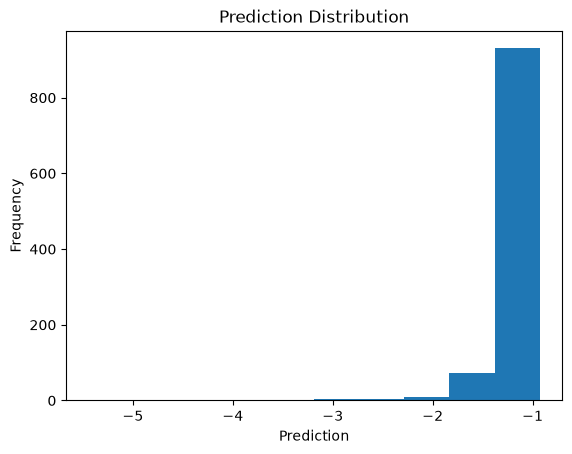

In [123]:
plt.hist(lof_pred)
plt.xlabel("Prediction")
plt.ylabel("Frequency")
plt.title("Prediction Distribution")
plt.show()

One Class SVM


In [124]:
model_svm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.05
)

model_svm.fit(X_train_processed)

,"nu nu: float, default=0.5An upper bound on the fraction of trainingerrors and a lower bound of the fraction of supportvectors. Should be in the interval (0, 1]. By default 0.5will be taken.",0.05
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1
Name,Type,Value


In [125]:
svm_pred = model_svm.decision_function(
    X_test_processed
)

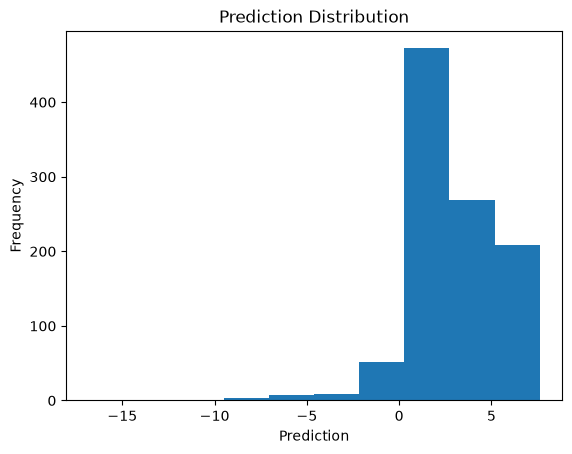

In [126]:
plt.hist(svm_pred)
plt.xlabel("Prediction")
plt.ylabel("Frequency")
plt.title("Prediction Distribution")
plt.show()

In [128]:
comparison_df = pd.DataFrame({
    "Isolation Forest": iso_pred,
    "Local Outlier Factor" : lof_pred,
    "One Class SVM" : svm_pred
})

In [135]:
comparison_df = pd.DataFrame({
    "Isolation Forest": -iso_pred,
    "Local Outlier Factor": -lof_pred,
    "One Class SVM": -svm_pred
})

scaler = MinMaxScaler()

scored_df = pd.DataFrame(
    scaler.fit_transform(comparison_df),
    columns=[
        "Isolation Forest Score",
        "Local Outlier Factor Score",
        "One Class SVM Score"
    ],
    index=comparison_df.index
)

scored_df.head()

,Isolation Forest Score,Local Outlier Factor Score,One Class SVM Score
0,0.034513,0.029547,0.179923
1,0.270214,0.031065,0.059706
2,0.028638,0.011371,0.195756
3,0.036181,0.021001,0.118468
4,0.073814,0.007198,0.068698


In [136]:
comparison_summary = pd.DataFrame({
    "Model": [
        "Isolation Forest",
        "Local Outlier Factor",
        "One Class SVM"
    ],
    "Mean Score": [
        scored_df["Isolation Forest Score"].mean(),
        scored_df["Local Outlier Factor Score"].mean(),
        scored_df["One Class SVM Score"].mean()
    ],
    "Std Score": [
        scored_df["Isolation Forest Score"].std(),
        scored_df["Local Outlier Factor Score"].std(),
        scored_df["One Class SVM Score"].std()
    ],
    "Max Score": [
        scored_df["Isolation Forest Score"].max(),
        scored_df["Local Outlier Factor Score"].max(),
        scored_df["One Class SVM Score"].max()
    ]
})

comparison_summary

,Model,Mean Score,Std Score,Max Score
0,Isolation Forest,0.152547,0.173855,1.0
1,Local Outlier Factor,0.047197,0.064765,1.0
2,One Class SVM,0.195112,0.103341,1.0


In [137]:
top_k = int(len(scored_df) * 0.05)

top_iso = set(
    scored_df["Isolation Forest Score"]
    .nlargest(top_k)
    .index
)

top_lof = set(
    scored_df["Local Outlier Factor Score"]
    .nlargest(top_k)
    .index
)

top_svm = set(
    scored_df["One Class SVM Score"]
    .nlargest(top_k)
    .index
)

print("Top 5% observations:", top_k)

print("\nPairwise overlap:")
print(
    "Isolation Forest ↔ LOF:",
    len(top_iso & top_lof)
)

print(
    "Isolation Forest ↔ One-Class SVM:",
    len(top_iso & top_svm)
)

print(
    "LOF ↔ One-Class SVM:",
    len(top_lof & top_svm)
)

print(
    "\nAll three models agree:",
    len(top_iso & top_lof & top_svm)
)

Top 5% observations: 51

Pairwise overlap:
Isolation Forest ↔ LOF: 6
Isolation Forest ↔ One-Class SVM: 29
LOF ↔ One-Class SVM: 14

All three models agree: 6


In [138]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

import numpy as np
import pandas as pd
import time

In [ ]:
def evaluate_stability(
    model_type,
    params,
    X_reference,
    X_test,
    n_runs=5,
    top_fraction=0.05,
    sample_fraction=0.80
):

    top_sets = []
    runtimes = []

    sample_size = int(len(X_reference) * sample_fraction)

    for seed in range(n_runs):

        rng = np.random.RandomState(seed)

        sample_indices = rng.choice(
            len(X_reference),
            size=sample_size,
            replace=False
        )

        X_sample = X_reference.iloc[sample_indices]

        if model_type == "Isolation Forest":

            model = IsolationForest(
                **params,
                random_state=seed,
                n_jobs=-1
            )

        elif model_type == "LOF":

            model = LocalOutlierFactor(
                **params,
                novelty=True
            )

        elif model_type == "One-Class SVM":

            model = OneClassSVM(
                **params
            )

        start = time.perf_counter()

        model.fit(X_sample)

        scores = -model.decision_function(X_test)

        runtime = time.perf_counter() - start
        runtimes.append(runtime)

        top_k = max(
            1,
            int(len(X_test) * top_fraction)
        )

        top_indices = set(
            np.argsort(scores)[-top_k:]
        )

        top_sets.append(top_indices)

    similarities = []

    for i in range(len(top_sets)):
        for j in range(i + 1, len(top_sets)):

            intersection = len(
                top_sets[i] & top_sets[j]
            )

            union = len(
                top_sets[i] | top_sets[j]
            )

            similarities.append(
                intersection / union
            )

    return {
        "Stability_Score": np.mean(similarities),
        "Stability_Std": np.std(similarities),
        "Runtime_Seconds": np.mean(runtimes)
    }

In [140]:
if_configs = [
    {
        "n_estimators": 100,
        "max_samples": "auto",
        "max_features": 1.0
    },
    {
        "n_estimators": 200,
        "max_samples": "auto",
        "max_features": 1.0
    },
    {
        "n_estimators": 300,
        "max_samples": "auto",
        "max_features": 1.0
    },
    {
        "n_estimators": 500,
        "max_samples": "auto",
        "max_features": 1.0
    },
    {
        "n_estimators": 300,
        "max_samples": 0.8,
        "max_features": 1.0
    },
    {
        "n_estimators": 300,
        "max_samples": "auto",
        "max_features": 0.8
    }
]

In [141]:
if_results = []

for i, params in enumerate(if_configs):

    result = evaluate_stability(
        model_type="Isolation Forest",
        params=params,
        X_reference=X_train_processed,
        X_test=X_test_processed,
        n_runs=5
    )

    result.update(params)
    result["Configuration"] = f"IF-{i+1}"

    if_results.append(result)

if_results = pd.DataFrame(if_results)

if_results = if_results.sort_values(
    "Stability_Score",
    ascending=False
)

if_results

,Stability_Score,Stability_Std,Runtime_Seconds,n_estimators,max_samples,max_features,Configuration
4,0.910806,0.036321,0.395302,300,0.8,1.0,IF-5
5,0.899963,0.031105,0.367939,300,auto,0.8,IF-6
2,0.886355,0.042468,0.363859,300,auto,1.0,IF-3
3,0.882532,0.033905,0.607292,500,auto,1.0,IF-4
1,0.855643,0.045017,0.249972,200,auto,1.0,IF-2
0,0.808500,0.075866,0.136842,100,auto,1.0,IF-1


In [142]:
lof_configs = [
    {
        "n_neighbors": 10,
        "contamination": "auto"
    },
    {
        "n_neighbors": 20,
        "contamination": "auto"
    },
    {
        "n_neighbors": 30,
        "contamination": "auto"
    },
    {
        "n_neighbors": 50,
        "contamination": "auto"
    },
    {
        "n_neighbors": 75,
        "contamination": "auto"
    }
]

In [ ]:
lof_results = []

for i, params in enumerate(lof_configs):

    result = evaluate_stability(
        model_type="LOF",
        params=params,
        X_reference=X_train_processed,
        X_test=X_test_processed,
        n_runs=5
    )

    result.update(params)
    result["Configuration"] = f"LOF-{i+1}"

    lof_results.append(result)

lof_results = pd.DataFrame(lof_results)

lof_results = lof_results.sort_values(
    "Stability_Score",
    ascending=False
)

lof_results

In [144]:
ocsvm_configs = []

for nu in [0.01, 0.03, 0.05, 0.10]:

    for gamma in [
        "scale",
        0.01,
        0.1,
        1.0
    ]:

        ocsvm_configs.append({
            "kernel": "rbf",
            "nu": nu,
            "gamma": gamma
        })

In [145]:
ocsvm_results = []

for i, params in enumerate(ocsvm_configs):

    result = evaluate_stability(
        model_type="One-Class SVM",
        params=params,
        X_reference=X_train_processed,
        X_test=X_test_processed,
        n_runs=5
    )

    result.update(params)
    result["Configuration"] = f"SVM-{i+1}"

    ocsvm_results.append(result)

ocsvm_results = pd.DataFrame(ocsvm_results)

ocsvm_results = ocsvm_results.sort_values(
    "Stability_Score",
    ascending=False
)

ocsvm_results

,Stability_Score,Stability_Std,Runtime_Seconds,kernel,nu,gamma,Configuration
14,0.984615,0.018842,0.059111,rbf,0.10,0.1,SVM-15
13,0.976923,0.018842,0.058584,rbf,0.10,0.01,SVM-14
1,0.969231,0.015385,0.007783,rbf,0.01,0.01,SVM-2
12,0.950435,0.016960,0.060098,rbf,0.10,scale,SVM-13
5,0.947299,0.037718,0.019949,rbf,0.03,0.01,SVM-6
9,0.940583,0.052276,0.032044,rbf,0.05,0.01,SVM-10
10,0.939615,0.029664,0.031514,rbf,0.05,0.1,SVM-11
15,0.869026,0.040704,0.061548,rbf,0.10,1.0,SVM-16
8,0.861537,0.020363,0.032297,rbf,0.05,scale,SVM-9
4,0.855043,0.030602,0.023141,rbf,0.03,scale,SVM-5


In [146]:
best_if = if_results.iloc[0]
best_lof = lof_results.iloc[0]
best_svm = ocsvm_results.iloc[0]

In [147]:
final_comparison = pd.DataFrame([
    {
        "Model": "Isolation Forest",
        "Best_Parameters": (
            f"n_estimators={best_if['n_estimators']}, "
            f"max_samples={best_if['max_samples']}, "
            f"max_features={best_if['max_features']}"
        ),
        "Stability_Score": best_if["Stability_Score"],
        "Stability_Std": best_if["Stability_Std"],
        "Runtime_Seconds": best_if["Runtime_Seconds"]
    },
    {
        "Model": "LOF",
        "Best_Parameters": (
            f"n_neighbors={best_lof['n_neighbors']}"
        ),
        "Stability_Score": best_lof["Stability_Score"],
        "Stability_Std": best_lof["Stability_Std"],
        "Runtime_Seconds": best_lof["Runtime_Seconds"]
    },
    {
        "Model": "One-Class SVM",
        "Best_Parameters": (
            f"nu={best_svm['nu']}, "
            f"gamma={best_svm['gamma']}"
        ),
        "Stability_Score": best_svm["Stability_Score"],
        "Stability_Std": best_svm["Stability_Std"],
        "Runtime_Seconds": best_svm["Runtime_Seconds"]
    }
])

final_comparison = final_comparison.sort_values(
    "Stability_Score",
    ascending=False
)

final_comparison

,Model,Best_Parameters,Stability_Score,Stability_Std,Runtime_Seconds
2,One-Class SVM,"nu=0.1, gamma=0.1",0.984615,0.018842,0.059111
1,LOF,n_neighbors=75,0.924665,0.016247,0.060330
0,Isolation Forest,"n_estimators=300, max_samples=0.8, max_feature...",0.910806,0.036321,0.395302


In [149]:
additional_ocsvm_configs = []

for nu in [0.10, 0.15, 0.20]:
    for gamma in [0.05, 0.10, 0.20]:
        additional_ocsvm_configs.append({
            "kernel": "rbf",
            "nu": nu,
            "gamma": gamma
        })

In [150]:
additional_results = []

for i, params in enumerate(additional_ocsvm_configs):

    result = evaluate_stability(
        model_type="One-Class SVM",
        params=params,
        X_reference=X_train_processed,
        X_test=X_test_processed,
        n_runs=5
    )

    result.update(params)
    result["Configuration"] = f"SVM-Additional-{i+1}"

    additional_results.append(result)

additional_results = pd.DataFrame(additional_results)

additional_results.sort_values(
    "Stability_Score",
    ascending=False
)

,Stability_Score,Stability_Std,Runtime_Seconds,kernel,nu,gamma,Configuration
3,1.000000,0.000000,0.087272,rbf,0.15,0.05,SVM-Additional-4
1,0.984615,0.018842,0.061704,rbf,0.10,0.10,SVM-Additional-2
4,0.976923,0.018842,0.086404,rbf,0.15,0.10,SVM-Additional-5
2,0.969376,0.022789,0.060204,rbf,0.10,0.20,SVM-Additional-3
7,0.961974,0.029232,0.114622,rbf,0.20,0.10,SVM-Additional-8
5,0.961829,0.023869,0.085973,rbf,0.15,0.20,SVM-Additional-6
6,0.957983,0.020230,0.117936,rbf,0.20,0.05,SVM-Additional-7
0,0.954427,0.028163,0.061359,rbf,0.10,0.05,SVM-Additional-1
8,0.954427,0.028163,0.115123,rbf,0.20,0.20,SVM-Additional-9


In [151]:
final_svm = OneClassSVM(
    kernel="rbf",
    nu=0.15,
    gamma=0.05
)

final_svm.fit(X_train_processed)

,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.05
,"nu nu: float, default=0.5An upper bound on the fraction of trainingerrors and a lower bound of the fraction of supportvectors. Should be in the interval (0, 1]. By default 0.5will be taken.",0.15
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1
Name,Type,Value


In [152]:
final_svm_predictions = final_svm.predict(
    X_test_processed
)

final_svm_scores = -final_svm.decision_function(
    X_test_processed
)

In [153]:
anomaly_count = np.sum(final_svm_predictions == -1)
normal_count = np.sum(final_svm_predictions == 1)

print("Normal observations:", normal_count)
print("Anomalous observations:", anomaly_count)

print(
    "Anomaly percentage:",
    round(anomaly_count / len(final_svm_predictions) * 100, 2),
    "%"
)

Normal observations: 879
Anomalous observations: 144
Anomaly percentage: 14.08 %


In [154]:
final_results = df.loc[
    X_test_processed.index
].copy()

final_results["Anomaly_Score"] = final_svm_scores

final_results["Anomaly_Label"] = np.where(
    final_svm_predictions == -1,
    "Anomaly",
    "Normal"
)

final_results = final_results.sort_values(
    "Anomaly_Score",
    ascending=False
)

final_results.head(20)

,Country,State,Year,City,Investment,Central_assistance_sanctioned,Central_assistance_released,Houses_sanctioned,Houses_grounded,Houses_completed,Anomaly_Score,Anomaly_Label
567,India,Bihar,"Calendar Year (Jan - Dec), 2025","Thakurganj, Town Panchayat",40.20,11.16,7.05,742.0,375.0,312.0,196.458031,Anomaly
620,India,Chhattisgarh,"Calendar Year (Jan - Dec), 2025","Chandrapur, Town Panchayat",24.09,9.86,8.26,629.0,629.0,615.0,172.355903,Anomaly
385,India,Bihar,"Calendar Year (Jan - Dec), 2025","Dhamdaha, Town Panchayat",43.81,10.11,4.04,674.0,135.0,NaN,141.521005,Anomaly
916,India,Gujarat,"Calendar Year (Jan - Dec), 2025","Por-Ramangamdi, Municipal Corporation",7.66,1.53,1.53,67.0,67.0,67.0,139.927519,Anomaly
96,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025","Palasa Kasibugga, Municipality",190.88,73.72,36.69,4872.0,4179.0,2412.0,88.514075,Anomaly
842,India,Gujarat,"Calendar Year (Jan - Dec), 2025","Gandevi, Municipality",70.99,22.60,19.06,1451.0,1339.0,1319.0,85.879929,Anomaly
6,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025","Amadalavalasa, Municipality",219.76,81.45,53.77,5399.0,4343.0,3139.0,82.864516,Anomaly
112,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025","Rajahmundry, Municipal Corporation",1171.00,319.06,195.42,20255.0,19457.0,13408.0,79.459664,Anomaly
277,India,Assam,"Calendar Year (Jan - Dec), 2025","North Guwahati, Town Panchayat",22.23,9.89,7.93,647.0,647.0,411.0,79.340684,Anomaly
296,India,Assam,"Calendar Year (Jan - Dec), 2025","Simaluguri, Town Panchayat",10.27,5.33,4.43,344.0,321.0,227.0,78.954043,Anomaly


In [155]:
if_results.to_csv(
    "../experiments/results/isolation_forest_tuning.csv",
    index=False
)

lof_results.to_csv(
    "../experiments/results/lof_tuning.csv",
    index=False
)

ocsvm_results.to_csv(
    "../experiments/results/one_class_svm_tuning.csv",
    index=False
)

final_comparison.to_csv(
    "../experiments/results/model_comparison.csv",
    index=False
)

print("Model comparison experiments saved.")

Model comparison experiments saved.


In [157]:
final_results.to_csv(
    "../experiments/results/final_svm_anomaly_results.csv",
    index=False
)

joblib.dump(
    final_svm,
    "../src/models/final_one_class_svm.joblib"
)

print("Final One-Class SVM saved.")

Final One-Class SVM saved.
